In [2]:
!pip install seaborn

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Defining tickers and dates
tickers = ["SPY" , "EWU" , "URTH" , "TLT" , "GLD" , "QQQ"]
start_date = "2021-08-25"
end_date = "2026-08-25"

Loads the Yahoo Finance data tool and nicnames it 'yf' and loads pandas and nicknames it 'pd'

Defines the list of our interested assets icnluding the exact start date and the end date of focus

In [4]:
raw_data = yf.download(tickers=tickers , start=start_date , end=end_date)

adj_close_data = raw_data['Close']

clean_data = adj_close_data.dropna()

[*********************100%***********************]  6 of 6 completed


Fetches the data using f.download
Although we are inteerested in the Adj Close price, recently yahoo fiance has already applied the mathematics to the Close price and dropped the Adj Close price, therefore we ask the data extraction to focus only on the 'Close' price.

In [5]:
# Calcualte daily percentage returns
returns = clean_data.pct_change()

returns = returns.dropna()

.pct_change() is a built in method inside pandas that calcualtes the percentage change from the previous raw by default.

The first row will show an error, so .dropna() has to be used to remove it.

In [6]:
# Calculate std. deviation using pandas
std_dev_daily = returns.std()

# Annualisation (over 252 days work year)
annual_volatility = std_dev_daily * np.sqrt(255)
annual_volatility

Ticker
EWU     0.164668
GLD     0.187880
QQQ     0.231267
SPY     0.173127
TLT     0.158380
URTH    0.164305
dtype: float64

In [7]:
# Weighted avg. returns

weights = np.array([1/6 , 1/6 , 1/6 , 1/6 , 1/6 , 1/6])

portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2021-08-26   -0.003286
2021-08-27    0.009659
2021-08-30    0.002608
2021-08-31   -0.002289
2021-09-01    0.002207
dtype: float64

Assigned equal weight to each 6 assets (1/6)

MATRIX.dot(MATRIX) is a function under pandas where as np.dot is a function under numpy but strips away the dates and titles

In [8]:
# Annualised standard deviation of portfolio_returns
std_dev_portfolio_returns = portfolio_returns.std()
# Annualisation
annual_volatility_portfolio_returns = std_dev_portfolio_returns * np.sqrt(255)

print('annual volatility portfolio returns = ' , annual_volatility_portfolio_returns)

annual volatility portfolio returns =  0.1303355637693041


In [9]:
# Correlation matrix
Correlation_matrix = returns.corr()
Correlation_matrix

Ticker,EWU,GLD,QQQ,SPY,TLT,URTH
Ticker,,,,,,
EWU,1.000000,0.316929,0.555282,0.668456,0.112434,0.764135
GLD,0.316929,1.000000,0.144059,0.146631,0.212589,0.208397
QQQ,0.555282,0.144059,1.000000,0.950216,0.078046,0.928825
SPY,0.668456,0.146631,0.950216,1.000000,0.086962,0.982150
TLT,0.112434,0.212589,0.078046,0.086962,1.000000,0.110455
URTH,0.764135,0.208397,0.928825,0.982150,0.110455,1.000000


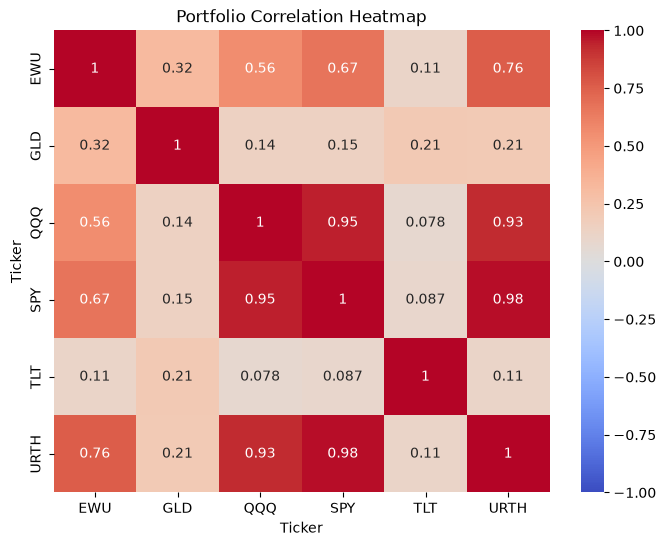

In [10]:
import seaborn as sns

# Set the size of the canvas
plt.figure(figsize=(8, 6))

# Generate the heatmap from your matrix
sns.heatmap(Correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# Add a title and display it
plt.title("Portfolio Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,6)) tells Matplotlib to create a blank canvas that is 8 inches wide and 6 inches tall before drawing anything  

sns.heatmap(...) tells the core Seaborn function that reads a matrix and assigns colors to the numbers  

annot=True short for annotate. Ofrce python to stamp the actual decimal. if set to false, it will give blank coloured boxes

cmap='coolwarm' This assigns the colour palette. It maps -1.0 to dark blue, 0.0 to white, and 1.0 to dark red.

vmin=-1, vmax=1 is a critical engineering constraint. It locks the colour scale to strict mathematical boundaries. If not, Seaborn would dynamically assign pure blue to the lowest number in the dataset and pure red to the highest which would misrepresent the actual risk relationships.


In [11]:
# Annualised covariance
cov_matrix = returns.cov() * 252    # variance scales linearly
print('Covariance Matrix is = ' , cov_matrix)

Covariance Matrix is =  Ticker       EWU       GLD       QQQ       SPY       TLT      URTH
Ticker                                                            
EWU     0.026797  0.009690  0.020898  0.018832  0.002898  0.020431
GLD     0.009690  0.034884  0.006186  0.004713  0.006251  0.006357
QQQ     0.020898  0.006186  0.052855  0.037598  0.002825  0.034878
SPY     0.018832  0.004713  0.037598  0.029620  0.002356  0.027609
TLT     0.002898  0.006251  0.002825  0.002356  0.024789  0.002841
URTH    0.020431  0.006357  0.034878  0.027609  0.002841  0.026678


In [12]:
portfolio_variance = weights.T @ cov_matrix @ weights
portfolio_volatility = np.sqrt(portfolio_variance)  #calculates the std dev
portfolio_volatility

np.float64(0.12956661567917763)

@ performs matrix multiplication where as * performs element wise multiplication

In [13]:
# Annualised return for each individual asset
annual_returns = returns.mean() * 252
# Total portfolio return using the dot product
port_returns = weights.T @ annual_returns
print('Portfolio Returns = ' , port_returns)

Portfolio Returns =  0.1140918832846668


In [14]:
# Calculate Sharpe ratio
risk_free_rate = 0.04
sharpe_ratio = (port_returns - risk_free_rate) / portfolio_volatility
print('Sharpe Ratio = ' , sharpe_ratio)

Sharpe Ratio =  0.5718439344601476


In [15]:
# Monte Carlo Simulation

# Number of portfolios to simulate
num_portfolios = 10000

# Storage arrays filled with zeros
all_weights = np.zeros((num_portfolios, len(returns.columns)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

# For loop simulation
for i in range(num_portfolios):
    # Generate 6 random numbers
    mcs_weights = np.random.random(len(returns.columns))
    # Normalise to sum up to exactly 1.0
    mcs_weights = mcs_weights / np.sum(mcs_weights)


    mcs_portfolio_returns = mcs_weights.T @ annual_returns
    mcs_portfolio_variance = mcs_weights.T @ cov_matrix @ mcs_weights
    mcs_portfolio_volatility = np.sqrt(mcs_portfolio_variance)

    mcs_sharpe_ratio = (mcs_portfolio_returns - risk_free_rate) / mcs_portfolio_volatility

    all_weights[i,:] = mcs_weights      # Pastes the 6 random weights generated in the current row where the loop is at
    ret_arr[i] = mcs_portfolio_returns
    vol_arr[i] = mcs_portfolio_volatility
    sharpe_arr[i] = mcs_sharpe_ratio

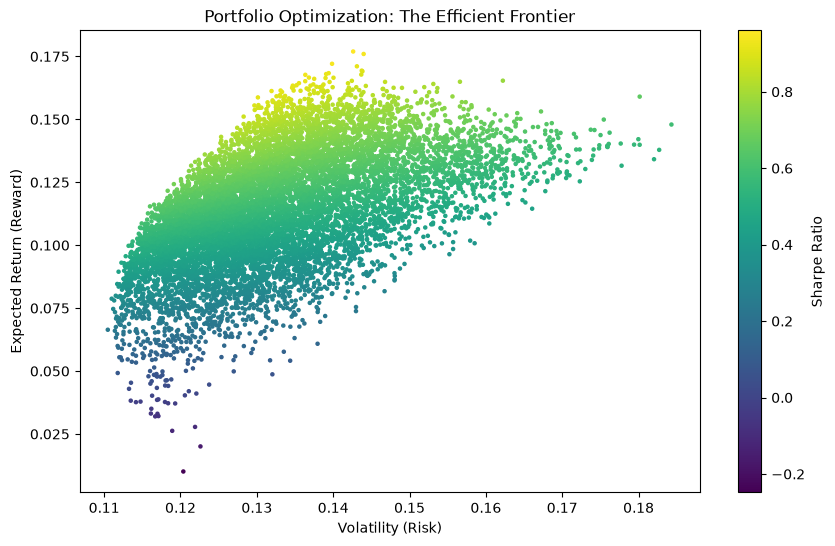

In [16]:
# Set the canvas size
plt.figure(figsize=(10, 6))

# Build the scatter plot
# c=sharpe_arr color-codes the dots, cmap='viridis' applies a color gradient, s=10 sets dot size
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=5)

# Add a color bar legend to the side
plt.colorbar(label='Sharpe Ratio')

# Add professional labels
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return (Reward)')
plt.title('Portfolio Optimization: The Efficient Frontier')

# Display the chart
plt.show()

(vol_arr, ret_arr) sets teh X-axis (risk) and the Y-axis (reward)   
c=sharpe_arr Links the colour (c) of each dot to its specific sharpe ratio  
cmap = 'viridis' Applies a specific colour gradient palette.  
s=5 sets the size of each dot

In [33]:
# Extract the best combination of values
max_sharpe_idx = sharpe_arr.argmax()

max_sharpe = sharpe_arr[max_sharpe_idx]
optimal_return = ret_arr[max_sharpe_idx]
optimal_risk = vol_arr[max_sharpe_idx]

# Formatted printing
print(f"Optimised Sharpe Ratio: {max_sharpe:.4f}")  #:.4f gives 4 dp
print(f"Optimum Annual Return: {optimal_return:.4f}")
print(f"Optimum Annual Volatility: {optimal_risk:.4f}")

print("\nOptimal Weights:")
optimal_weights = all_weights[max_sharpe_idx,:]

for ticker, weight_opt in zip(returns.columns , optimal_weights):
    print(f"{ticker}: {weight_opt*100:.2f}%")

Optimised Sharpe Ratio: 0.9602
Optimum Annual Return: 0.1769
Optimum Annual Volatility: 0.1426

Optimal Weights:
EWU: 16.98%
GLD: 63.53%
QQQ: 0.07%
SPY: 17.62%
TLT: 1.16%
URTH: 0.63%


.Argmax() scans the absolute highest value, and returns the index of it

returns.columns is Panda function to give the names of all columns of a table  
zip() pairs items together, so the columns heading adn the optimal weights  

The loop unzips those pairs created inside the zip function one by one, assigning the name to ticker and the decimal to weight. It then prints them out, multiplying the decimal by 100 and formatting it to two decimal places (.2f) si it is printed as a clean percentage